# **Gemma 4 : Byte for byte, the most capable open models**
- Launched on 02 Apr 2026

**Industry-leading capabilities and mobile-first AI**

> - [Gemma 4](https://blog.google/innovation-and-ai/technology/developers-tools/gemma-4/) in four versatile sizes: Effective 2B (E2B), Effective 4B (E4B), 26B Mixture of Experts (MoE) and 31B Dense.

> - The entire family moves beyond simple chat to handle complex logic and agentic workflows.

> - Well-suited for reasoning, agentic workflows, coding, and multimodal understanding

### Setup

In [1]:
# Runtime type : T4

# Install the necessary dependencies
!pip install -U transformers torch accelerate

# 1. Delete preinstalled version
!pip uninstall -y torch torchvision torchaudio

# 2. Install CUDA 12.8 (that works well with T4 GPU)
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128

  Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl.metadata (29 kB)
Using cached torch-2.11.0-cp312-cp312-manylinux_2_28_x86_64.whl (530.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchvision 0.25.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
torchaudio 2.10.0+cu128 requires torch==2.10.0, but you have torch 2.11.0 which is incompatible.
Found existing installation: torch 2.11.0
Uninstalling torch-2.11.0:
  Successfully uninstalled torch-2.11.0
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━

In [9]:
# from google.colab import drive
# drive.mount('/content/drive')

# Alternative Mount from Colab UI -> File

### Kaggle API Credentials

In [1]:
from google.colab import userdata
import os

KAGGLE_USERNAME = userdata.get('KAGGLE_USERNAME')
KAGGLE_KEY = userdata.get('KAGGLE_KEY')

os.environ["KAGGLE_USERNAME"] = KAGGLE_USERNAME
os.environ["KAGGLE_KEY"] = KAGGLE_KEY

In [2]:
import kagglehub
import torch
from transformers import AutoProcessor, AutoModelForCausalLM

# Getting model from Kaggle hub
# MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-26b-a4b")
MODEL_PATH = kagglehub.model_download("google/gemma-4/transformers/gemma-4-e2b-it")

# Load model
processor = AutoProcessor.from_pretrained(MODEL_PATH)
model = AutoModelForCausalLM.from_pretrained(
    MODEL_PATH,
    dtype=torch.bfloat16,
    device_map="auto"
)

# model

Loading weights:   0%|          | 0/2011 [00:00<?, ?it/s]

In [3]:
import torch

print(f"1. GPU model : {torch.cuda.get_device_name(0)}")
print(f"2. GPU architecture (Capability): {torch.cuda.get_device_capability(0)}")
print(f"3. PyTorch supported architecture: {torch.cuda.get_arch_list()}")

1. GPU model : Tesla T4
2. GPU architecture (Capability): (7, 5)
3. PyTorch supported architecture: ['sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


## **1. Gemma - Chat**

In [4]:
from rich.console import Console
from rich.panel import Panel
from rich.markdown import Markdown

question_msg = "What is Google Universal Commerce Protocol"

# Prompt
messages = [
    {"role": "system", "content": "You are an AI expert in Agent Interoperability and Standardisation.  If you do not know say you do not know.  Answer in concise bullet points."},
    {"role": "user", "content": question_msg},
]

# Process input
text = processor.apply_chat_template(
    messages,
    tokenize=False,
    add_generation_prompt=True,
    enable_thinking=True  # False
)
inputs = processor(text=text, return_tensors="pt").to(model.device)
input_len = inputs["input_ids"].shape[-1]

# Generate output
outputs = model.generate(**inputs, max_new_tokens=1024)
response = processor.decode(outputs[0][input_len:], skip_special_tokens=False)

# Parse thinking
processor.parse_response(response)
print(180*"*")

# Console
console = Console()
parsed = processor.parse_response(response)

console.print(Panel(question_msg, title="[bold cyan]🧠 question", border_style="cyan"))

# Thinking process output (panel format)
console.print(Panel(parsed['thinking'], title="[bold cyan]🧠 Thinking Process", border_style="cyan"))

# Final answer output
console.print(Panel(parsed['content'], title="[bold green]🐘 Assistant's Response", border_style="green"))

print(parsed['content'])

************************************************************************************************************************************************************************************


╭────────────────────────────────────────────────── 🧠 question ──────────────────────────────────────────────────╮
│ What is Google Universal Commerce Protocol                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭────────────────────────────────────────────── 🧠 Thinking Process ──────────────────────────────────────────────╮
│ Thinking Process:                                                                                               │
│                                                                                                                 │
│ 1.  **Analyze the Request:** The user is asking "What is Google Universal Commerce Protocol (UCP)?"             │
│ 2.  **Identify the Persona:** The required persona is an "AI expert in Agent Interoperability and               │
│ Standardisation."                                                                                               │
│ 3.  **Determine Knowledge Base (UCP):** I need to check my knowledge regarding Google Universal Commerce        │
│ Protocol (UCP).                                                                                                 │
│ 4.  **Information Retrieval & Verification:**                                                                   │
│     *   What is UCP? It is a set of standards/protocols designed to unify commerce interactions (product        │
│ discovery, pricing, inventory, checkout) across various channels (web, app, voice, smart devices) using         │
│ Google's ecosystem.                                                                                             │
│     *   Its goal is interoperability between merchants, platforms, and Google services.                         │
│     *   It often relates to Google Merchant Center and other Google Shopping features.                          │
│ 5.  **Structure the Answer:** The response must be in concise bullet points, reflecting the expertise           │
│ requested.                                                                                                      │
│ 6.  **Draft Key Points (Self-Correction/Refinement):** Ensure the points focus on *what* it is, *why* it        │
│ exists, and *how* it functions, rather than just a definition.                                                  │
│                                                                                                                 │
│     *   *Initial thought:* It connects stores. (Too simple)                                                     │
│     *   *Refined thought:* It standardizes data exchange. (Better)                                              │
│     *   *Focus:* Interoperability, unified commerce, schema/data structure.                                     │
│                                                                                                                 │
│ 7.  **Final Output Generation:** (Produce the concise bullet points.)                                           │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

╭──────────────────────────────────────────── 🐘 Assistant's Response ────────────────────────────────────────────╮
│ *   **Definition:** Google Universal Commerce Protocol (UCP) is a set of standardized data models, APIs, and    │
│ communication protocols designed to enable seamless interoperability between merchants, platforms, and various  │
│ Google services for commerce.                                                                                   │
│ *   **Goal:** To create a unified commerce experience by standardizing how product information, pricing,        │
│ inventory, and transaction data are exchanged across different channels (e.g., Google Shopping, mobile apps,    │
│ voice assistants).                                                                                              │
│ *   **Functionality:** It acts as a common language or schema that allows different systems to understand and   │
│ exchange commerce-related data reliably, regardless of the underlying platform technology.                      │
│ *   **Interoperability Focus:** The primary objective is to break down silos between e-commerce platforms and   │
│ Google services, allowing merchants to leverage Google's infrastructure across multiple touchpoints.            │
│ *   **Impact:** Facilitates richer product discovery, more accurate inventory management, and smoother          │
│ cross-platform purchasing experiences for end-users.                                                            │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

*   **Definition:** Google Universal Commerce Protocol (UCP) is a set of standardized data models, APIs, and communication protocols designed to enable seamless interoperability between merchants, platforms, and various Google services for commerce.
*   **Goal:** To create a unified commerce experience by standardizing how product information, pricing, inventory, and transaction data are exchanged across different channels (e.g., Google Shopping, mobile apps, voice assistants).
*   **Functionality:** It acts as a common language or schema that allows different systems to understand and exchange commerce-related data reliably, regardless of the underlying platform technology.
*   **Interoperability Focus:** The primary objective is to break down silos between e-commerce platforms and Google services, allowing merchants to leverage Google's infrastructure across multiple touchpoints.
*   **Impact:** Facilitates richer product discovery, more accurate inventory management, and smoother cr

## **2. Gemma - Image**

In [5]:
# 1. Load the model and processor
processor = AutoProcessor.from_pretrained(MODEL_PATH)

### Example 1 :

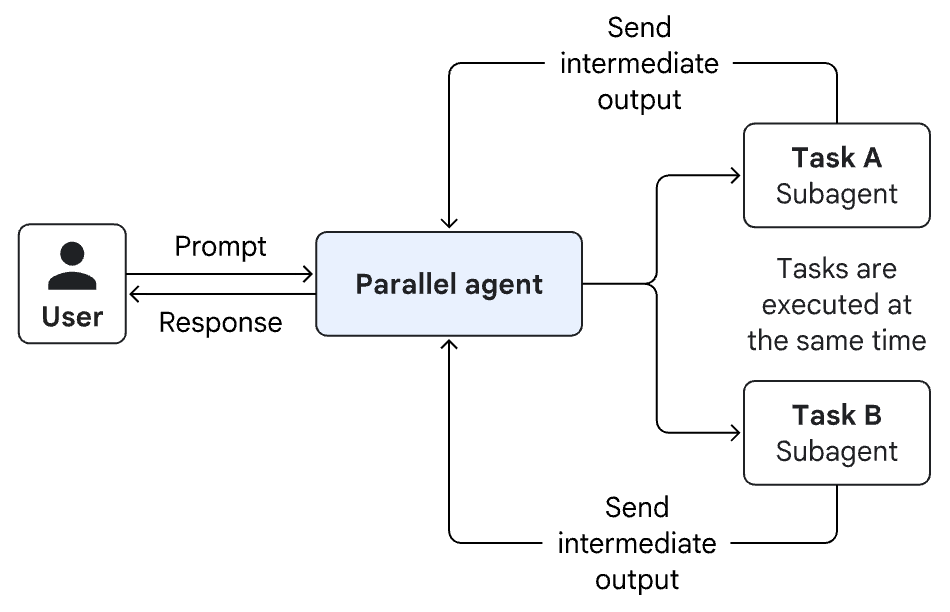

In [13]:
from PIL import Image

# 2. Load the image
# You can load from a URL or local file path
image_path = "/content/drive/MyDrive/Images/MultiAgentSystems_Parallel_pattern.png"
image_1 = Image.open(image_path)

image_1

In [14]:
# 3. Prepare the prompt
prompt_1 = "<start_of_turn>user\n<|image|>\nYou are an AI expert in Agent Architecture and Worksflows.  If you do not know say you do not know.  Answer in concise bullet points.  Describe this image in detail.<end_of_turn>\n<start_of_turn>model\n"

# 4. Process inputs
inputs = processor(text=prompt_1, images=image_1, return_tensors="pt").to(model.device)

# 5. Generate output
# Note: Gemma 4 handles images via special tokens managed by the processor
outputs = model.generate(**inputs, max_new_tokens=500)
response = processor.decode(outputs[0], skip_special_tokens=True)

print(response)

<start_of_turn>user

You are an AI expert in Agent Architecture and Worksflows.  If you do not know say you do not know.  Answer in concise bullet points.  Describe this image in detail.<end_of_turn>
<start_of_turn>model
thought
Here's a thinking process to construct the detailed image description:

1.  **Analyze the Request:** The user wants a detailed description of the provided image, specifically structured as an AI expert describing Agent Architecture and Workflows.

2.  **Deconstruct the Image (Element by Element):** I need to scan the image and identify all components, interactions, and labels.

    *   **User Input Block:** A silhouette labeled "User."
    *   **Prompt Interaction:** An arrow labeled "Prompt" goes from the "User" block to the central agent.
    *   **Central Agent Block:** A dark rectangular block labeled "Parallel agent."
    *   **Response Interaction:** An arrow labeled "Response" goes from the "Parallel agent" back to the "User" block (indicating a cycle or

### Example 2 :

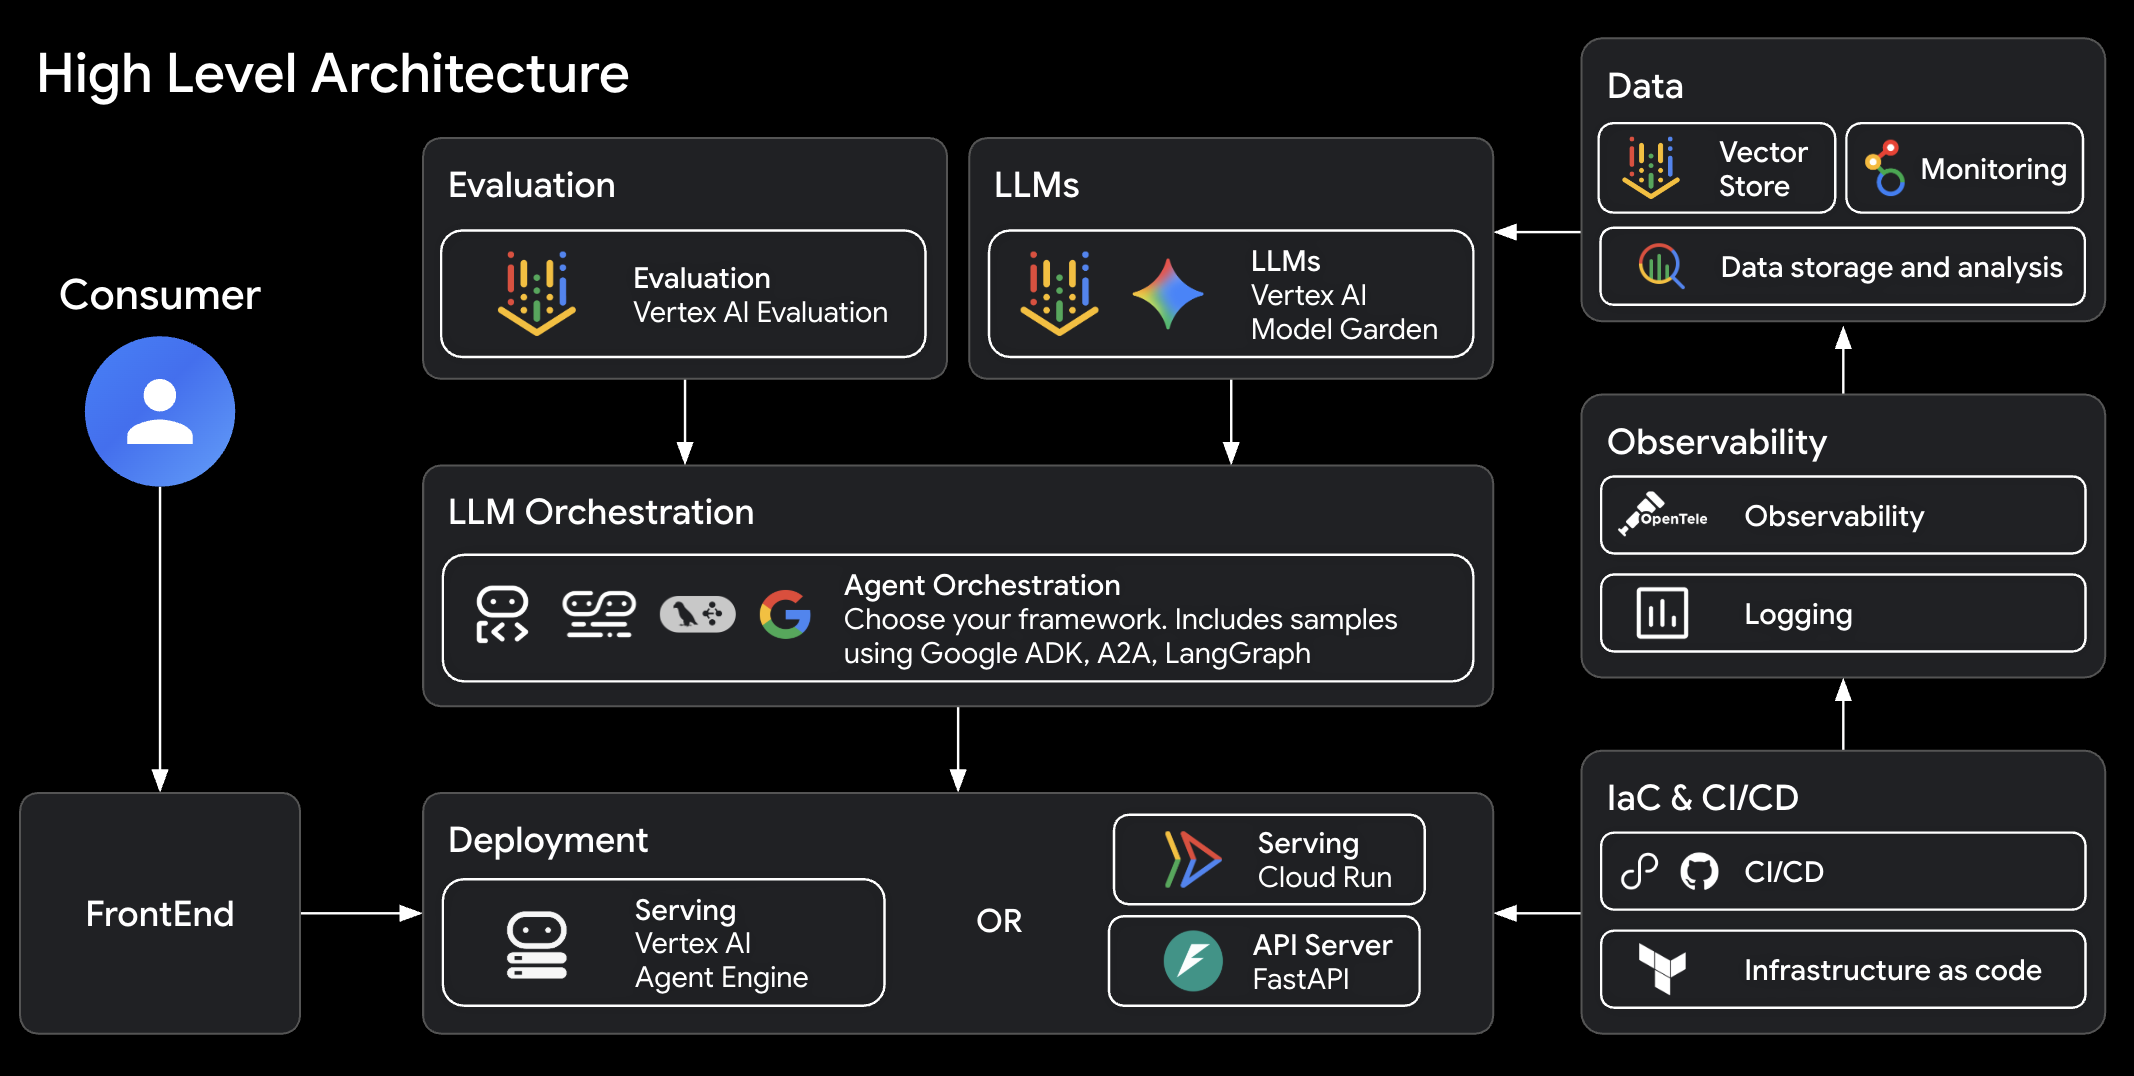

In [15]:
# 2. Load the image
# You can load from a URL or local file path
image_path = "/content/drive/MyDrive/Images/Google_ASP_HL_Architecture.png"
image_2 = Image.open(image_path)

image_2

In [16]:
# 3. Prepare the prompt
prompt_2 = "<start_of_turn>user\n<|image|>\nYou are an AI expert in Agent Architecture and Worksflows.  If you do not know say you do not know.  Answer in concise bullet points.  Describe this image in detail.<end_of_turn>\n<start_of_turn>model\n"

# 4. Process inputs
inputs = processor(text=prompt_2, images=image_2, return_tensors="pt").to(model.device)

# 5. Generate output
# Note: Gemma 4 handles images via special tokens managed by the processor
outputs = model.generate(**inputs, max_new_tokens=500)
response = processor.decode(outputs[0], skip_special_tokens=True)

print(response)

<start_of_turn>user

You are an AI expert in Agent Architecture and Worksflows.  If you do not know say you do not know.  Answer in concise bullet points.  Describe this image in detail.<end_of_turn>
<start_of_turn>model
thought
The user wants me to describe the provided image in detail.
The image is a complex diagram illustrating an Agent Architecture and Workflows, specifically showing the flow from Frontend to various components (LLM Orchestration, Deployment, etc.).

I need to go through the diagram section by section and capture the flow and the components shown in each section.

The overall structure shows:
1.  **Consumer** (represented by a person icon) flows to **Frontend**.
2.  **Frontend** flows to **Deployment** (OR) to **iac & CI/CD** (OR) to **Infrastructure as code**.
3.  **Frontend** flows to **LLM Orchestration**.
4.  **LLM Orchestration** flows to **LLMs**.
5.  **LLMs** flow to **Evaluation**.
6.  **Evaluation** flows to **LLM Orchestration** (or seems to feed back).
7

### 📚 Learn More

- [Gemma 4 model card](https://ai.google.dev/gemma/docs/core/model_card_4)
- [Kaggle - Gemma 4](https://www.kaggle.com/models/google/gemma-4/)
- [Prompt with images and text using Gemma library](https://ai.google.dev/gemma/docs/core/gemma_library)

---

| Original Author |
| --- |
| [Sam Au](http://linkedin.com/in/samaujs) |